In [32]:
import numpy as np
import math
import matplotlib.pylab as plt

In [ ]:
N = 1000
J = 2   
g = 9.81
angle = 30.5*math.pi/180
speed = 50
mass = 250
area = 0.93
density = 1.2
k = area*density/(2*mass)
dt = 2*speed*math.sin(angle)/(g*N)
d = dt*dt/2

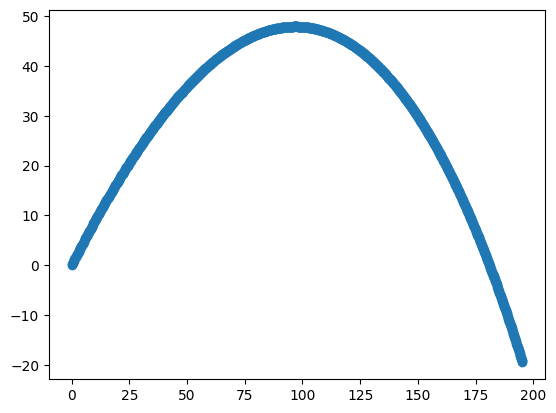

In [34]:
X = np.zeros(N)
Y = np.zeros(N)
VX = np.zeros(N)
VY = np.zeros(N)
AX = np.zeros(N)
AY = np.zeros(N)

X[0]=Y[0]=0
VX[0] = speed*math.cos(angle)
VY[0] = speed*math.sin(angle)
v = math.sqrt(VX[0]**2 + VY[0]**2)
AX[0] = -k*v*VX[0]
AY[0] = -g-k*v*VY[0]
p = VX[0]*AX[0] + VY[0]*AY[0]
X[1] = X[0]+dt*VX[0]+d*AX[0]
Y[1] = Y[0]+dt*VY[0]+d*AY[0]
VX[1] = VX[0]+dt*AX[0]-d*k*(v*AX[0]+p*VX[0]/v)
VY[1] = VY[0]+dt*AY[0]-d*k*(v*AY[0]+p*VY[0]/v)
v = math.sqrt(VX[1]**2+VY[1]**2)
AX[1] = -k*v*VX[1]
AY[1] = -g-k*v*VY[1]

D2 = 2*dt
D3 = dt/3
for i in range(N - 2):
    X[i+2] = X[i]+D2*VX[i+1]
    Y[i+2] = Y[i]+D2*VY[i+1]
    VX[i+2] = VX[i]+D2*AX[i+1]
    VY[i+2] = VY[i]+D2*AY[i+1]
    v = math.sqrt(VX[i+2]**2 + VY[i+2]**2)
    AX[i+2] = -k*v*VX[i+2]
    AY[i+2] = -g-k*v*VY[i+2]

    X[i + 2] = X[i]+D3*(VX[i+2]+4*VX[i+1]+VX[i])
    Y[i + 2] = Y[i]+D3*(VY[i+2]+4*VY[i+1]+VY[i])
    VX[i+2] = VX[i]+D3*(AX[i+2]+4*AX[i+1]+AX[i])
    VY[i+2] = VY[i]+D3*(AY[i+2]+4*AY[i+1]+AY[i])

plt.scatter(X,Y)
